# Connect Google Drive

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import torch
print(f"Is CUDA available? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

Is CUDA available? True
GPU Name: NVIDIA L4


# Install **pytorch-tabnet, optuna**

In [3]:
!pip install pytorch-tabnet optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 37.7 MB/s eta 0:00:00


# Important Libraries

In [4]:
import torch
import shap
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from pytorch_tabnet.metrics import Metric
from pytorch_tabnet.tab_model import TabNetRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
import joblib
import os
import gc

# Sentinel-2

## Data Loading


In [5]:
s2_file_path = "/content/drive/MyDrive/Thesis/Train_data/s2_with_veg_data.csv"

print("Loading data...")
s2df = pd.read_csv(s2_file_path)
print("Data is loaded")

print("\nData preparation...")

s2df1 = s2df.loc[s2df["age"] != 5].dropna()

s2df1.drop(columns=["age", "stock_per_ha", "height", "poly_id", "S2_Date"], axis=1, inplace=True)

s2_y = s2df1["basal_area"]
S2_X = s2df1.drop(columns=["basal_area"], axis=1)

S2_train, S2_val, s2_train, s2_val = train_test_split(S2_X, s2_y, test_size=0.15, random_state=42, stratify=s2_y)
S2_train, S2_test, s2_train, s2_test = train_test_split(S2_train, s2_train, test_size=0.15, random_state=42, stratify=s2_train)

print(f"\nDatasets are read! S2_train shape: {S2_train.shape}, S2_test shape: {S2_test.shape}, S2_val shape: {S2_val.shape}")

Loading data...
Data is loaded

Data preparation...

Datasets are read! S2_train shape: (284286, 52), S2_test shape: (50169, 52), S2_val shape: (59022, 52)


## Training with optimized Hyper-parameters


### XGBoost Model Training, Evaluation and Plot


Starting XGBoost training...
[0]	validation_0-rmse:19.14975
[1]	validation_0-rmse:19.10096
[2]	validation_0-rmse:19.05358
[3]	validation_0-rmse:19.00766
[4]	validation_0-rmse:18.96199
[5]	validation_0-rmse:18.91715
[6]	validation_0-rmse:18.87321
[7]	validation_0-rmse:18.82946
[8]	validation_0-rmse:18.78510
[9]	validation_0-rmse:18.74360
[10]	validation_0-rmse:18.70261
[11]	validation_0-rmse:18.66247
[12]	validation_0-rmse:18.62331
[13]	validation_0-rmse:18.58331
[14]	validation_0-rmse:18.54449
[15]	validation_0-rmse:18.50670
[16]	validation_0-rmse:18.47003
[17]	validation_0-rmse:18.43309
[18]	validation_0-rmse:18.39568
[19]	validation_0-rmse:18.35777
[20]	validation_0-rmse:18.32158
[21]	validation_0-rmse:18.28632
[22]	validation_0-rmse:18.25107
[23]	validation_0-rmse:18.21633
[24]	validation_0-rmse:18.18317
[25]	validation_0-rmse:18.14915
[26]	validation_0-rmse:18.11592
[27]	validation_0-rmse:18.08438
[28]	validation_0-rmse:18.05092
[29]	validation_0-rmse:18.01941
[30]	validation_0-rm

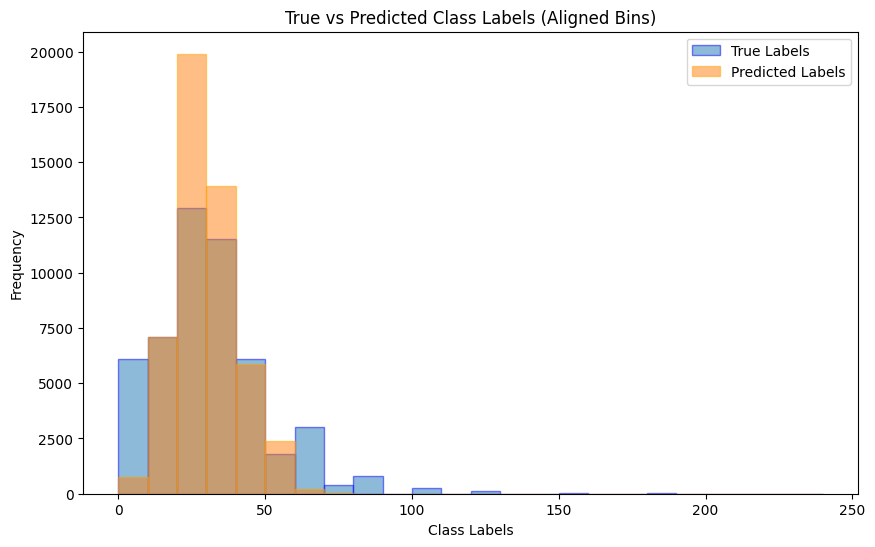

In [8]:
print("\nStarting XGBoost training...")
# Best Regressor Params:
# {'subsample': 0.7,
# 'n_estimators': 2000,
# 'min_child_weight': 7,
# 'max_depth': 15,
# 'learning_rate': 0.01,
# 'gamma': 0.5,
# 'colsample_bytree': 0.7}

XGBmodel_basal_area = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    tree_method='hist',
    n_estimators=2000,
    max_depth = 15,
    learning_rate = 0.01,
    colsample_bytree = 0.7,
    subsample = 0.7,
    min_child_weight = 7,
    gamma = 0.5,
    device="cuda",
    early_stopping_rounds=50
)

XGBmodel_basal_area.fit(
    S2_train, s2_train,
    eval_set=[(S2_val, s2_val)]
)
print("XGBoost Training finished")

# Evaluate
print("\nEvaluating Final Model on Test Set...")
y_pred_final = XGBmodel_basal_area.predict(S2_test)

rmse_final = np.sqrt(mean_squared_error(s2_test, y_pred_final))
mae_final = mean_absolute_error(s2_test, y_pred_final)

print(f"Final Model RMSE: {rmse_final:.3f}")
print(f"Final Model MAE: {mae_final:.3f}")

# Plot
plt.figure(figsize=(10, 6))
shared_bins = np.arange(0, 250, 10)

plt.hist(s2_test, label='True Labels', alpha=0.5, bins=shared_bins, edgecolor='blue')
plt.hist(y_pred_final, label='Predicted Labels', alpha=0.5, bins=shared_bins, edgecolor='orange')

plt.xlabel('Class Labels')
plt.ylabel('Frequency')
plt.legend()
plt.title('True vs Predicted Class Labels (Aligned Bins)')
plt.show()

### Tabnet Model Training, Evaluation and Plot

In [9]:
S2_train_np = S2_train.values.astype(np.float32) if isinstance(S2_train, pd.DataFrame) else S2_train.astype(np.float32)
s2_train_np = s2_train.values.astype(np.float32).reshape(-1, 1) if isinstance(s2_train, pd.Series) else s2_train.astype(np.float32).reshape(-1, 1)

S2_val_np = S2_val.values.astype(np.float32) if isinstance(S2_val, pd.DataFrame) else S2_val.astype(np.float32)
s2_val_np = s2_val.values.astype(np.float32).reshape(-1, 1) if isinstance(s2_val, pd.Series) else s2_val.astype(np.float32).reshape(-1, 1)

S2_test_np = S2_test.values.astype(np.float32) if isinstance(S2_test, pd.DataFrame) else S2_test.astype(np.float32)
s2_test_np = s2_test.values.astype(np.float32).reshape(-1, 1) if isinstance(s2_test, pd.Series) else s2_test.astype(np.float32).reshape(-1, 1)

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 467.53609| valid_rmse: 18.85014|  0:00:07s
epoch 1  | loss: 300.69178| valid_rmse: 19.69167|  0:00:13s
epoch 2  | loss: 279.47601| valid_rmse: 19.2501 |  0:00:19s
epoch 3  | loss: 270.5878| valid_rmse: 18.52626|  0:00:25s
epoch 4  | loss: 269.3385| valid_rmse: 18.14526|  0:00:32s
epoch 5  | loss: 263.82555| valid_rmse: 18.03782|  0:00:38s
epoch 6  | loss: 262.31767| valid_rmse: 17.81165|  0:00:45s
epoch 7  | loss: 259.28527| valid_rmse: 17.00148|  0:00:51s
epoch 8  | loss: 255.92476| valid_rmse: 16.89823|  0:00:58s
epoch 9  | loss: 254.44415| valid_rmse: 16.12088|  0:01:04s
epoch 10 | loss: 257.09562| valid_rmse: 16.80125|  0:01:10s
epoch 11 | loss: 253.6324| valid_rmse: 16.26265|  0:01:17s
epoch 12 | loss: 253.21345| valid_rmse: 15.96104|  0:01:24s
epoch 13 | loss: 250.10215| valid_rmse: 15.80919|  0:01:31s
epoch 14 | loss: 247.8041| valid_rmse: 15.80756|  0:01:37s
epoch 15 | loss: 247.7796| valid_rmse: 15.77006|  0:01:44s
epoch 16 | loss: 247.46108| valid_rmse: 15.64

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Evaluating Final Model on Test Set...
Final Tabnet Model RMSE: 15.094
Final Tabnet Model MAE: 10.679


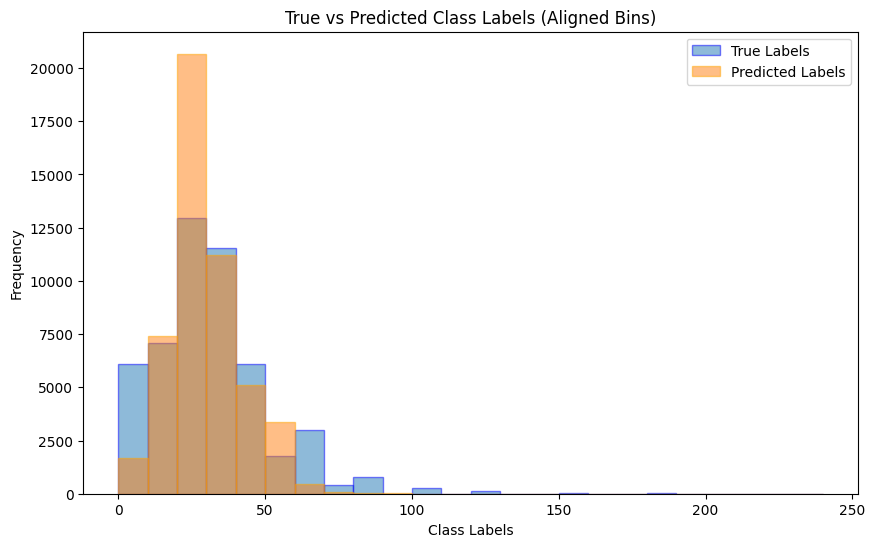

In [10]:
# Best Parameters Found:
#   n_d: 32
#   n_steps: 4
#   gamma: 1.5951703215483652
#   lambda_sparse: 1.0879664568254845e-05
#   lr: 0.018433371831400695


Tabnet_basal_area = TabNetRegressor(
    n_d= 32,
    n_a= 32,
    n_steps= 4,
    gamma= 1.5951703215483652,
    lambda_sparse= 1.0879664568254845e-05,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.018433371831400695),
    mask_type='entmax',
    device_name='cuda',
    verbose=1
)

Tabnet_basal_area.fit(
    X_train=S2_train_np, y_train=s2_train_np,
    eval_set=[(S2_val_np, s2_val_np)],
    eval_name=['valid'],
    eval_metric=['rmse'],
    max_epochs=150,
    patience=20,
    batch_size=4096,
    virtual_batch_size=512
)

# Evaluate
print("\nEvaluating Final Model on Test Set...")
y_pred_final = Tabnet_basal_area.predict(S2_test_np)

rmse_final = np.sqrt(mean_squared_error(s2_test_np, y_pred_final))
mae_final = mean_absolute_error(s2_test_np, y_pred_final)

print(f"Final Tabnet Model RMSE: {rmse_final:.3f}")
print(f"Final Tabnet Model MAE: {mae_final:.3f}")

# Plot
plt.figure(figsize=(10, 6))

shared_bins = np.arange(0, 250, 10)

plt.hist(s2_test_np, label='True Labels', alpha=0.5, bins=shared_bins, edgecolor='blue')
plt.hist(y_pred_final, label='Predicted Labels', alpha=0.5, bins=shared_bins, edgecolor='orange')

plt.xlabel('Class Labels')
plt.ylabel('Frequency')
plt.legend()
plt.title('True vs Predicted Class Labels (Aligned Bins)')
plt.show()

# Alpha Earth Foundation + Sentinel-2

## Data Loading

In [5]:
aef_file_path = "/content/drive/MyDrive/Thesis/Train_data/s2_aef_with_veg_data.csv"

print("Loading data...")
aefdf = pd.read_csv(aef_file_path)
print("Data is loaded")

print("\nData preparation...")

aefdf1 = aefdf.loc[aefdf["age"] != 5].dropna()

aefdf1.drop(columns=["age", "stock_per_ha", "height", "poly_id", "S2_Date"], axis=1, inplace=True)

aef_y = aefdf1["basal_area"]
AEF_X = aefdf1.drop(columns=["basal_area"], axis=1)

AEF_train, AEF_val, aef_train, aef_val = train_test_split(AEF_X, aef_y, test_size=0.15, random_state=42, stratify=aef_y)
AEF_train, AEF_test, aef_train, aef_test = train_test_split(AEF_train, aef_train, test_size=0.15, random_state=42, stratify=aef_train)

print(f"\nDatasets are read! AEF_train shape: {AEF_train.shape}, AEF_test shape: {AEF_test.shape}, AEF_val shape: {AEF_val.shape}")

Loading data...
Data is loaded

Data preparation...

Datasets are read! AEF_train shape: (284117, 308), AEF_test shape: (50139, 308), AEF_val shape: (58987, 308)


##Training with optimized Hyper-parameters

### XGBoost Model Training, Evaluation and Plot


Starting XGBoost training...
[0]	validation_0-rmse:18.59117
[1]	validation_0-rmse:18.06806
[2]	validation_0-rmse:17.61783
[3]	validation_0-rmse:17.21476
[4]	validation_0-rmse:16.84953
[5]	validation_0-rmse:16.52461
[6]	validation_0-rmse:16.25422
[7]	validation_0-rmse:16.01628
[8]	validation_0-rmse:15.81143
[9]	validation_0-rmse:15.62006
[10]	validation_0-rmse:15.44995
[11]	validation_0-rmse:15.29787
[12]	validation_0-rmse:15.16391
[13]	validation_0-rmse:15.03993
[14]	validation_0-rmse:14.92136
[15]	validation_0-rmse:14.81760
[16]	validation_0-rmse:14.72250
[17]	validation_0-rmse:14.63362
[18]	validation_0-rmse:14.54681
[19]	validation_0-rmse:14.47401
[20]	validation_0-rmse:14.40568
[21]	validation_0-rmse:14.34515
[22]	validation_0-rmse:14.28910
[23]	validation_0-rmse:14.22473
[24]	validation_0-rmse:14.18074
[25]	validation_0-rmse:14.13836
[26]	validation_0-rmse:14.09248
[27]	validation_0-rmse:14.06099
[28]	validation_0-rmse:14.02221
[29]	validation_0-rmse:13.98127
[30]	validation_0-rm

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [15:57:24] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Final Model RMSE: 8.845
Final Model MAE: 5.537


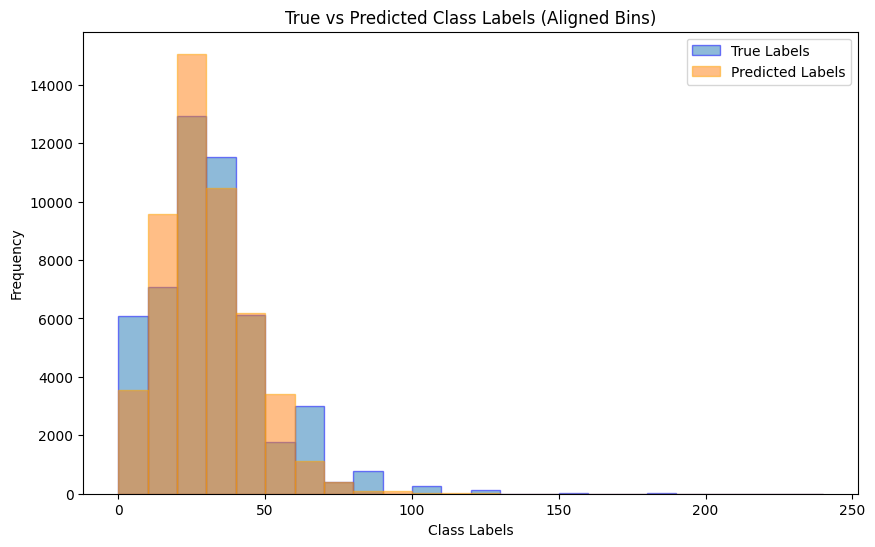

In [6]:
print("\nStarting XGBoost training...")
# Best Regressor Params:
# {'subsample': 0.9,
# 'n_estimators': 2000,
# 'min_child_weight': 7,
# 'max_depth': 9,
# 'learning_rate': 0.1,
# 'gamma': 0.1,
# 'colsample_bytree': 0.9}

XGBmodel_basal_area = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    tree_method='hist',
    n_estimators=2000,
    max_depth = 9,
    learning_rate = 0.1,
    colsample_bytree = 0.9,
    subsample = 0.9,
    min_child_weight = 7,
    gamma = 0.1,
    device="cuda",
    early_stopping_rounds=50
)

XGBmodel_basal_area.fit(
    AEF_train, aef_train,
    eval_set=[(AEF_val, aef_val)]
)
print("XGBoost Training finished")

# Evaluate
print("\nEvaluating Final Model on Test Set...")
y_pred_final = XGBmodel_basal_area.predict(AEF_test)

rmse_final = np.sqrt(mean_squared_error(aef_test, y_pred_final))
mae_final = mean_absolute_error(aef_test, y_pred_final)

print(f"Final Model RMSE: {rmse_final:.3f}")
print(f"Final Model MAE: {mae_final:.3f}")

# Plot
plt.figure(figsize=(10, 6))
shared_bins = np.arange(0, 250, 10)

plt.hist(aef_test, label='True Labels', alpha=0.5, bins=shared_bins, edgecolor='blue')
plt.hist(y_pred_final, label='Predicted Labels', alpha=0.5, bins=shared_bins, edgecolor='orange')

plt.xlabel('Class Labels')
plt.ylabel('Frequency')
plt.legend()
plt.title('True vs Predicted Class Labels (Aligned Bins)')
plt.show()

### Tabnet Model Training, Evaluation and Plot

In [7]:
AEF_train_np = AEF_train.values.astype(np.float32) if isinstance(AEF_train, pd.DataFrame) else AEF_train.astype(np.float32)
aef_train_np = aef_train.values.astype(np.float32).reshape(-1, 1) if isinstance(aef_train, pd.Series) else aef_train.astype(np.float32).reshape(-1, 1)

AEF_val_np = AEF_val.values.astype(np.float32) if isinstance(AEF_val, pd.DataFrame) else AEF_val.astype(np.float32)
aef_val_np = aef_val.values.astype(np.float32).reshape(-1, 1) if isinstance(aef_val, pd.Series) else aef_val.astype(np.float32).reshape(-1, 1)

AEF_test_np = AEF_test.values.astype(np.float32) if isinstance(AEF_test, pd.DataFrame) else AEF_test.astype(np.float32)
aef_test_np = aef_test.values.astype(np.float32).reshape(-1, 1) if isinstance(aef_test, pd.Series) else aef_test.astype(np.float32).reshape(-1, 1)

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 392.65009| valid_rmse: 19.1847 |  0:00:07s
epoch 1  | loss: 217.83458| valid_rmse: 18.87   |  0:00:14s
epoch 2  | loss: 201.53176| valid_rmse: 18.36217|  0:00:21s
epoch 3  | loss: 188.70202| valid_rmse: 17.52511|  0:00:27s
epoch 4  | loss: 178.07492| valid_rmse: 16.65327|  0:00:34s
epoch 5  | loss: 167.53708| valid_rmse: 15.92518|  0:00:40s
epoch 6  | loss: 156.69649| valid_rmse: 14.77827|  0:00:47s
epoch 7  | loss: 147.36748| valid_rmse: 14.06759|  0:00:53s
epoch 8  | loss: 138.64455| valid_rmse: 13.28778|  0:01:00s
epoch 9  | loss: 128.44427| valid_rmse: 12.75516|  0:01:07s
epoch 10 | loss: 121.86726| valid_rmse: 12.28938|  0:01:13s
epoch 11 | loss: 113.53847| valid_rmse: 11.63017|  0:01:20s
epoch 12 | loss: 105.57871| valid_rmse: 11.20155|  0:01:26s
epoch 13 | loss: 101.04098| valid_rmse: 10.83779|  0:01:33s
epoch 14 | loss: 94.71903| valid_rmse: 10.50104|  0:01:40s
epoch 15 | loss: 88.5788 | valid_rmse: 10.28446|  0:01:46s
epoch 16 | loss: 84.56541| valid_rmse: 10.

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Evaluating Final Model on Test Set...
Final Tabnet Model RMSE: 6.147
Final Tabnet Model MAE: 4.054


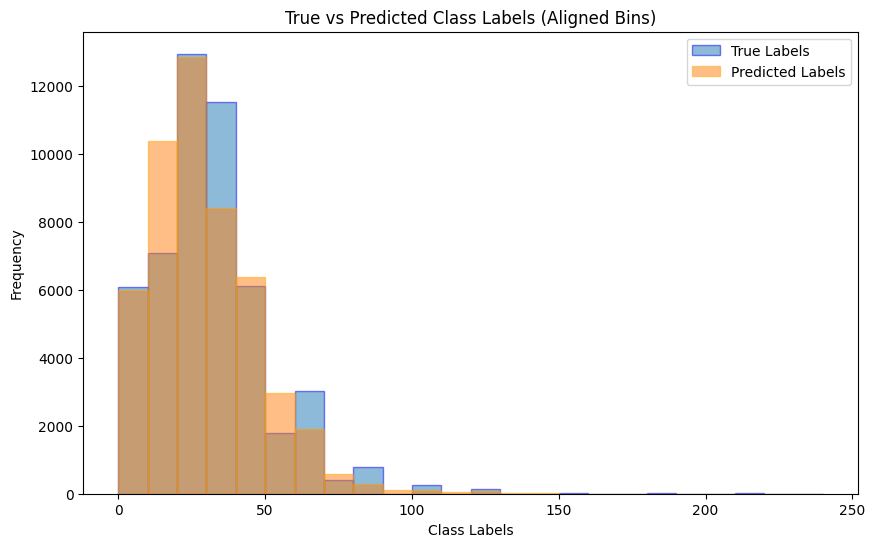

In [8]:
# Best Parameters Found:
#   n_d: 64
#   n_steps: 3
#   gamma: 1.3779293684095355
#   lambda_sparse: 0.0030606365389410283
#   lr: 0.012381881637587166


Tabnet_basal_area = TabNetRegressor(
    n_d= 64,
    n_a= 64,
    n_steps= 3,
    gamma= 1.3779293684095355,
    lambda_sparse= 0.0030606365389410283,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.012381881637587166),
    mask_type='entmax',
    device_name='cuda',
    verbose=1
)

Tabnet_basal_area.fit(
    X_train=AEF_train_np, y_train=aef_train_np,
    eval_set=[(AEF_val_np, aef_val_np)],
    eval_name=['valid'],
    eval_metric=['rmse'],
    max_epochs=150,
    patience=20,
    batch_size=4096,
    virtual_batch_size=512
)

# Evaluate
print("\nEvaluating Final Model on Test Set...")
y_pred_final = Tabnet_basal_area.predict(AEF_test_np)

rmse_final = np.sqrt(mean_squared_error(aef_test_np, y_pred_final))
mae_final = mean_absolute_error(aef_test_np, y_pred_final)

print(f"Final Tabnet Model RMSE: {rmse_final:.3f}")
print(f"Final Tabnet Model MAE: {mae_final:.3f}")

# Plot
plt.figure(figsize=(10, 6))

shared_bins = np.arange(0, 250, 10)

plt.hist(aef_test_np, label='True Labels', alpha=0.5, bins=shared_bins, edgecolor='blue')
plt.hist(y_pred_final, label='Predicted Labels', alpha=0.5, bins=shared_bins, edgecolor='orange')

plt.xlabel('Class Labels')
plt.ylabel('Frequency')
plt.legend()
plt.title('True vs Predicted Class Labels (Aligned Bins)')
plt.show()

# Feature Importance Analyses on Alpha Earth Foundation + Sentinel-2 dataset

## XGBoost SHAP value

In [9]:
feature_names = AEF_train.columns.tolist()

print("Initializing SHAP TreeExplainer...")
explainer = shap.TreeExplainer(XGBmodel_basal_area)

print("Calculating SHAP values...")
shap_values = explainer.shap_values(AEF_test)

Initializing SHAP TreeExplainer...
Calculating SHAP values...


### Top 20 Features

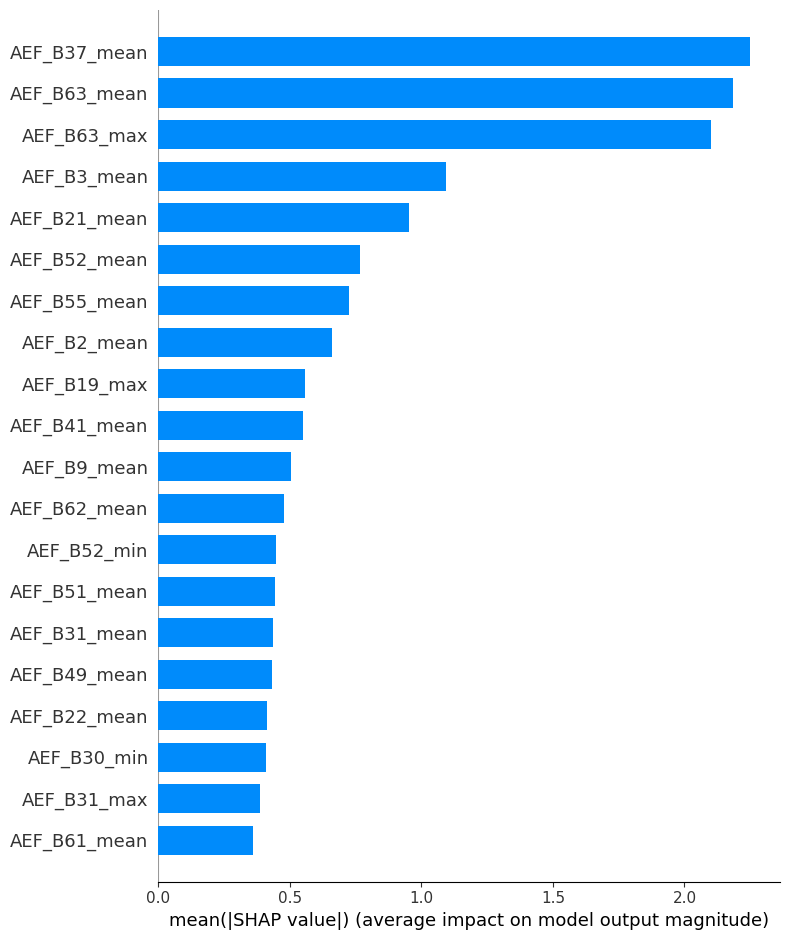

In [10]:
shap.summary_plot(shap_values, AEF_test, feature_names=feature_names, plot_type="bar")

### Top 100 Features

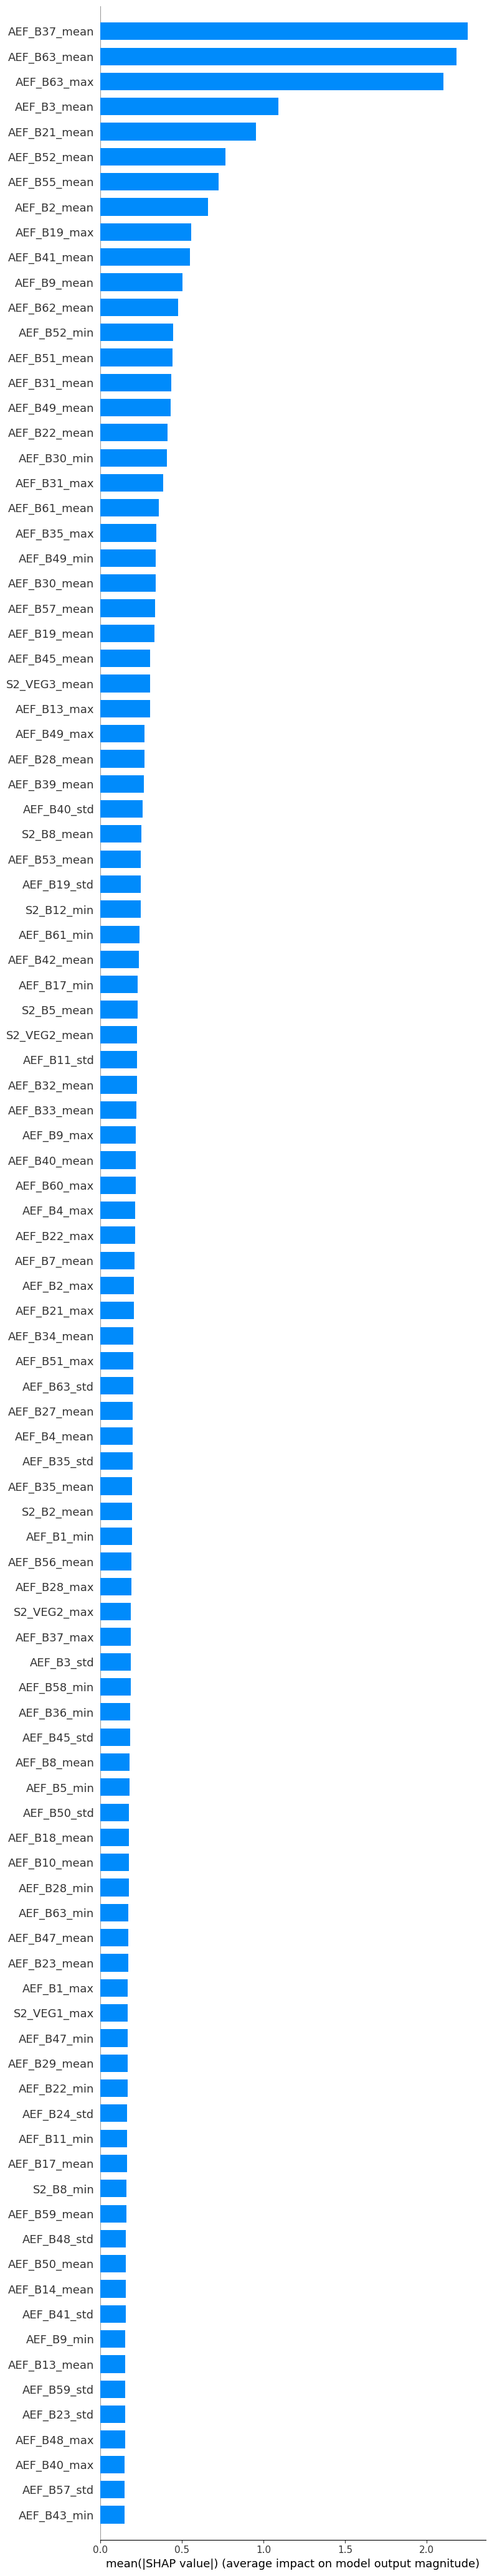

In [11]:
shap.summary_plot(shap_values, AEF_test, feature_names=feature_names, plot_type="bar", max_display=100)

## Tabnet SHAP value

In [14]:
import shap

feature_names = AEF_train.columns.tolist()

# Create a small "Test" sample to explain
test_indices = np.random.choice(AEF_test_np.shape[0], 2000, replace=False)
X_test_sample = AEF_test_np[test_indices]

# Initialize the SHAP Explainer
print("Initializing SHAP Explainer...")
explainer = shap.KernelExplainer(
    lambda x: Tabnet_basal_area.predict(x).flatten(),
    shap.kmeans(AEF_train_np, 100)
)

# Calculate SHAP values for the test sample
print("Calculating SHAP values...")
shap_values = explainer.shap_values(X_test_sample)

Initializing SHAP Explainer...
Calculating SHAP values...


  0%|          | 0/2000 [00:00<?, ?it/s]

### Top 20 Features

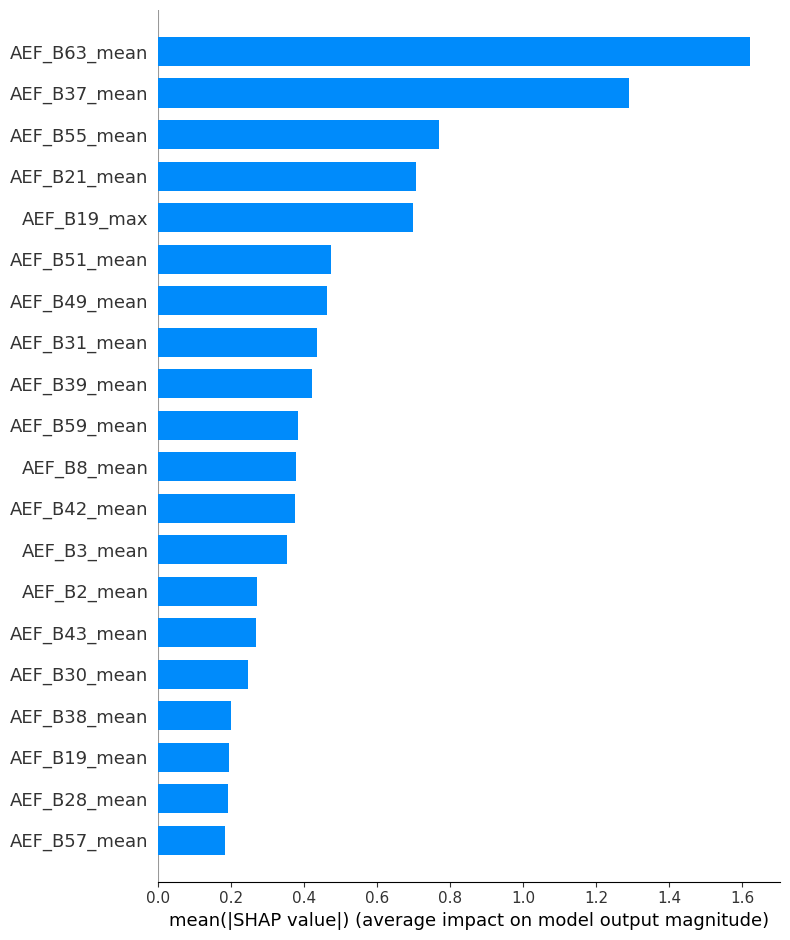

In [15]:
shap.summary_plot(shap_values, AEF_test_np, feature_names=feature_names, plot_type="bar")

### Top 100 Features

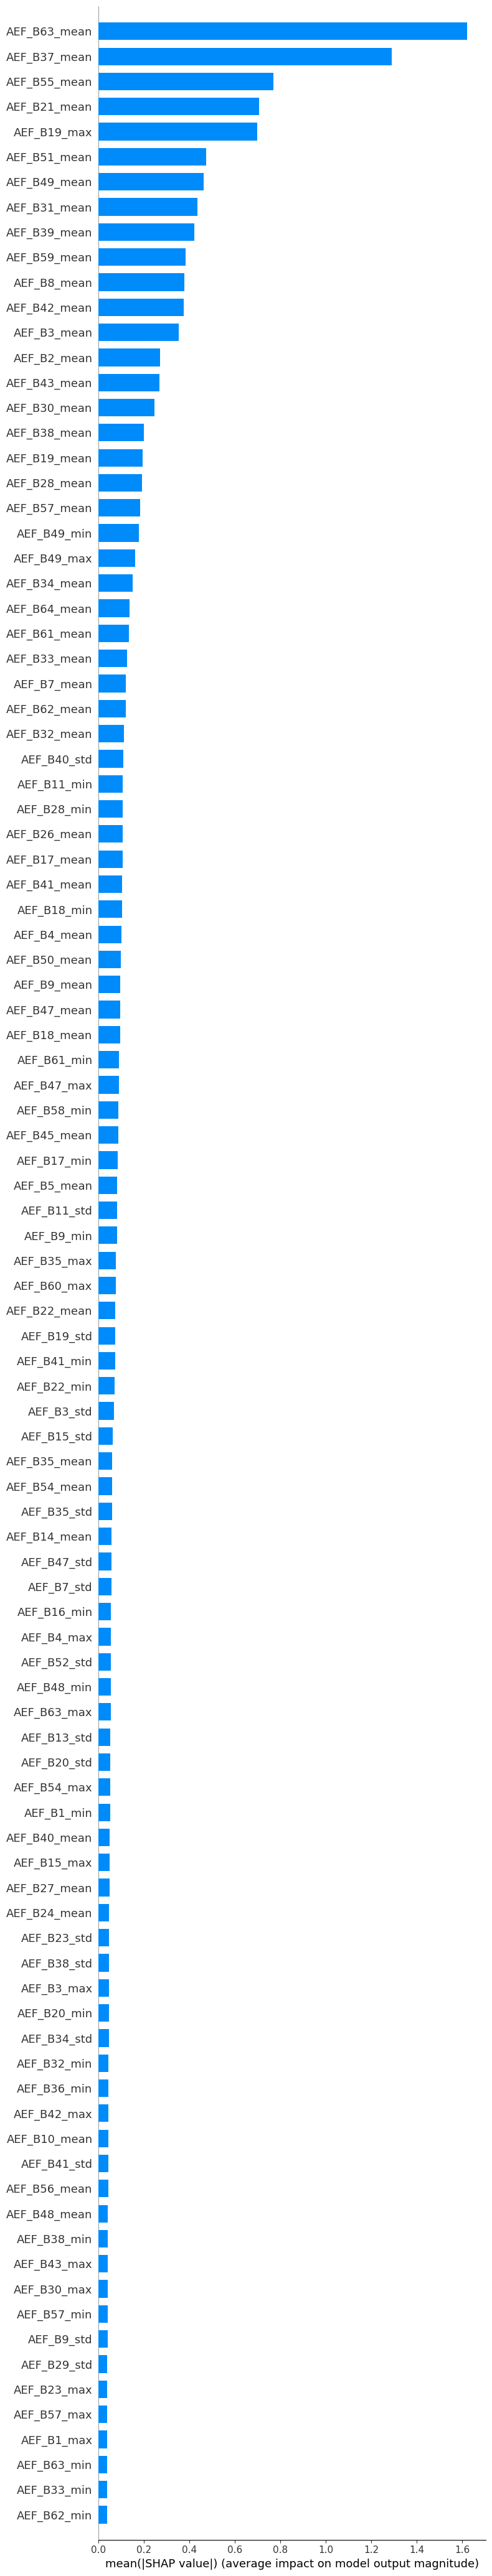

In [16]:
shap.summary_plot(shap_values, AEF_test_np, feature_names=feature_names, plot_type="bar", max_display = 100)